In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

### Load the data

In [2]:
# csv_path = "future-gc00-daily-prices.csv"
# data = pd.read_csv(
#     csv_path,
#     parse_dates=["Date"],
#     dayfirst=False,
#     index_col="Date"
# )

In [3]:
data = pd.read_csv('future-gc00-daily-prices.csv')
data.head()

,Date,Open,High,Low,Close
0,01/02/2013,"1,676.40","1,695.40","1,670.90","1,688.80"
1,01/02/2014,"1,204.50","1,230.80","1,202.50","1,225.20"
2,01/02/2015,"1,184.00","1,194.90","1,167.30","1,186.20"
3,01/02/2018,"1,305.30","1,320.40","1,304.60","1,316.10"
4,01/02/2019,"1,285.00","1,291.00","1,280.60","1,284.10"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724 entries, 0 to 3723
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3724 non-null   object
 1   Open    3724 non-null   object
 2   High    3724 non-null   object
 3   Low     3724 non-null   object
 4   Close   3724 non-null   object
dtypes: object(5)
memory usage: 145.6+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'],dayfirst=False)
ts = data.set_index('Date')
ts.head()

,Open,High,Low,Close
Date,,,,
2013-01-02,"1,676.40","1,695.40","1,670.90","1,688.80"
2014-01-02,"1,204.50","1,230.80","1,202.50","1,225.20"
2015-01-02,"1,184.00","1,194.90","1,167.30","1,186.20"
2018-01-02,"1,305.30","1,320.40","1,304.60","1,316.10"
2019-01-02,"1,285.00","1,291.00","1,280.60","1,284.10"


In [6]:
ts.sort_index(inplace=True)
ts.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.10
2009-04-27,915.00,919.70,905.80,908.20
2009-04-28,907.20,907.70,884.60,893.60
2009-04-29,894.00,904.00,888.30,900.50
2009-04-30,898.60,900.80,880.10,891.20


In [7]:
ts.shape

(3724, 4)

### Data Preprocessing

In [8]:
# Clean the "Close" column

# data["Close"].replace([np.inf, -np.inf], np.nan, inplace=True)
# data.dropna(subset=["Close"], inplace=True)

In [9]:
ts['Close'] = ts['Close'].replace(',','', regex=True)
ts['Close'] = pd.to_numeric(ts['Close'], errors='coerce')

In [10]:
ts.head()

,Open,High,Low,Close
Date,,,,
2009-04-24,905.50,915.40,904.20,914.1
2009-04-27,915.00,919.70,905.80,908.2
2009-04-28,907.20,907.70,884.60,893.6
2009-04-29,894.00,904.00,888.30,900.5
2009-04-30,898.60,900.80,880.10,891.2


### Create a time plot

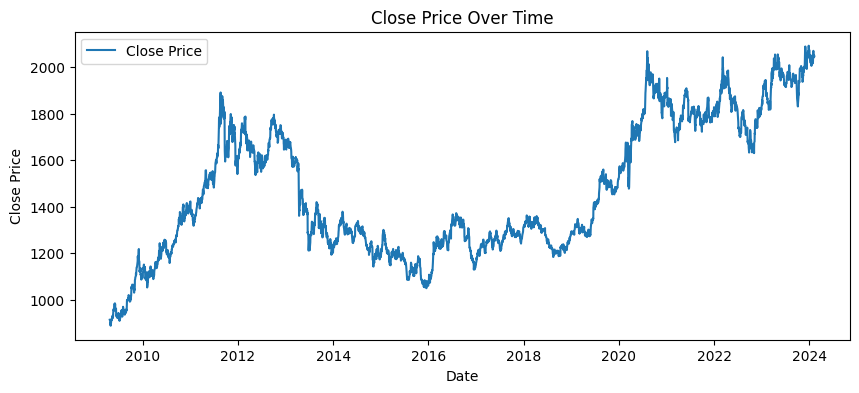

In [24]:
# Plotting the original Close price
plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts["Close"], label='Close Price')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

- not stationary because there is a clear trend
- there is non-constant variance at different time points

### ADF & Stationarity

In [26]:
# Perform the Augmented Dickey-Fuller test on the original series

data = ts

result_original = adfuller(data["Close"])
print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")
if result_original[1] < 0.05:    
    print("Interpretation: The original series is Stationary.\n")
else:    
    print("Interpretation: The original series is Non-Stationary.\n")

ADF Statistic (Original): -1.4367
p-value (Original): 0.5646
Interpretation: The original series is Non-Stationary.



In [30]:
# Apply first-order differencing

data['Close_Diff'] = data['Close'].diff()

result_diff = adfuller(data["Close_Diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:    
    print("Interpretation: The differenced series is Stationary.")
else:    
    print("Interpretation: The differenced series is Non-Stationary.")

ADF Statistic (Differenced): -19.1308
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


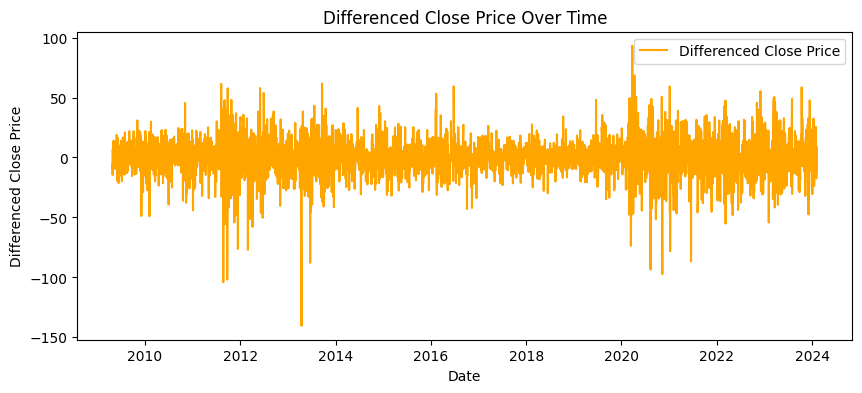

In [32]:
# Plotting the differenced Close price
plt.figure(figsize=(10,4))
plt.plot(data.index, data['Close_Diff'], label='Differenced Close Price', color='orange')
plt.title('Differenced Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()

### Finding the ARIMA terms

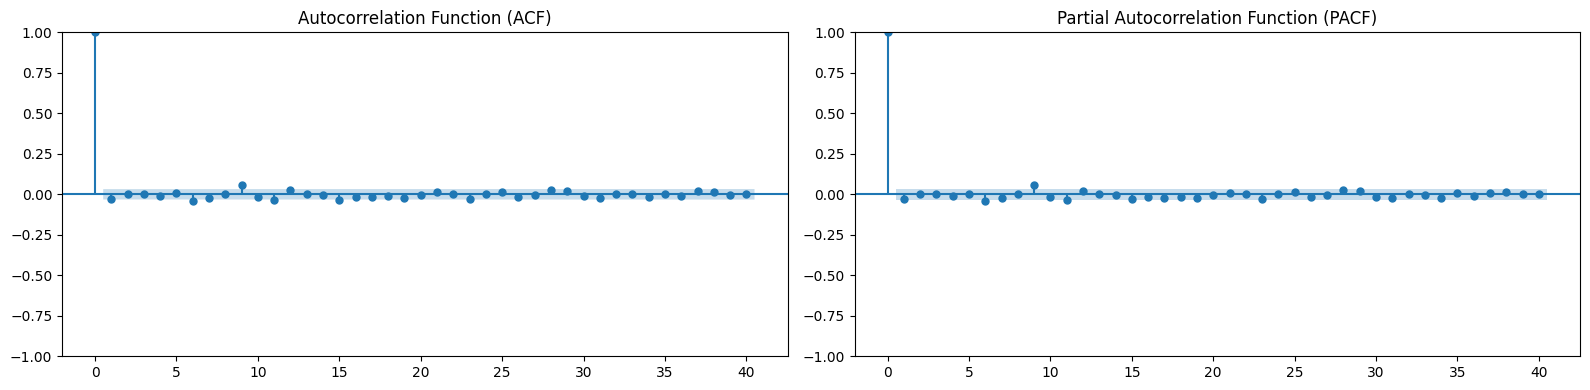

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
# ACF plot
plot_acf(data['Close_Diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
# PACF plot
plot_pacf(data['Close_Diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

## Forecasting

### train/test workflow

In [35]:
# Split data into train and test
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]
# Fit ARIMA model
model = ARIMA(train["Close"], order=(1,1,1))
model_fit = model.fit()

C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### Visualize our time series

C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\aksha\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


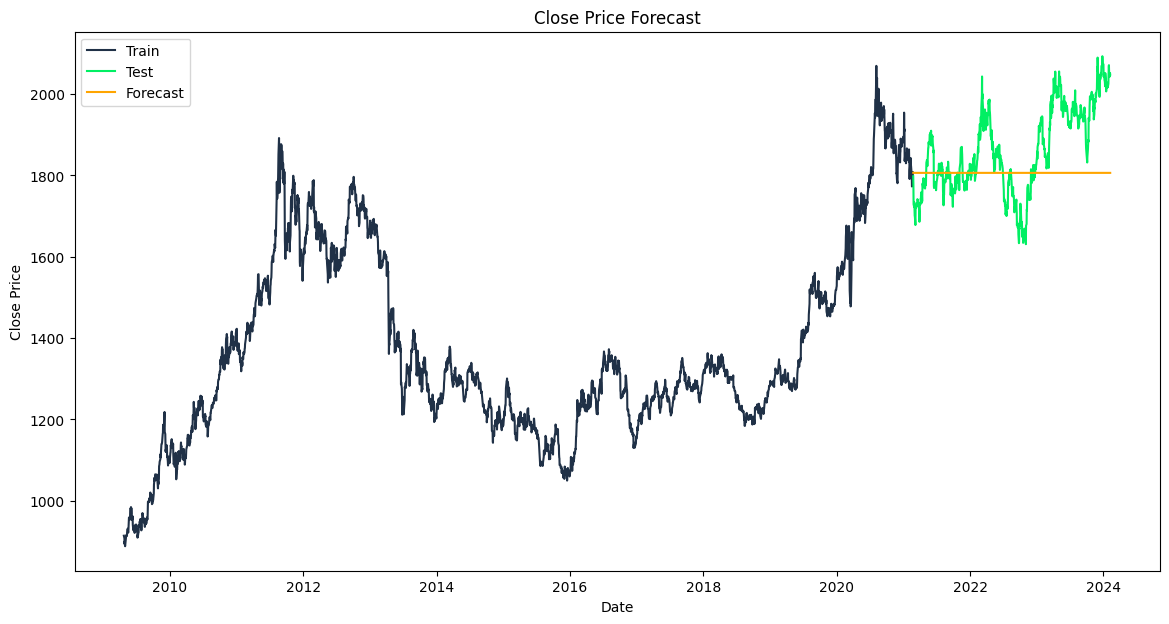

In [36]:
# Forecast
forecast = model_fit.forecast(steps=len(test))
# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train["Close"], label='Train', color='#203147')
plt.plot(test.index, test["Close"], label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

### Evaluate model statistics

In [38]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

AIC: 24602.974260669092
BIC: 24620.971282308823


In [39]:
forecast = forecast[:len(test)]
test_close = test["Close"][:len(forecast)]
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")

RMSE: 118.5339
